In [9]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)

(60000, 28, 28)
(60000,)


In [10]:
def FullyConnectedLayer(W, x, b):
  j = W @ x + b
  return j

def ReLULayer(x):
 x = np.maximum(0, x)
 return x

def softmax(x):
 exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
 sum_exp_x = np.sum(exp_x, axis=0, keepdims=True)
 softmax_x = exp_x / sum_exp_x
 return softmax_x

def Loss(y_pred, y_batch):
  batch_size = len(y_batch)
  v = y_pred[y_batch, np.arange(batch_size)]
  result = -np.log(v)
  return(np.mean(result))

W_FCLayer3 = np.random.randn(128, 784)* 0.1
W_FCLayer2 = np.random.randn(64, 128)* 0.1
W_FCLayer1 = np.random.randn(10, 64)* 0.1

b_FCLayer3 = np.zeros((128, 1))
b_FCLayer2 = np.zeros((64, 1))
b_FCLayer1 = np.zeros((10, 1))

LayerProduction = {
}
LossStock = []

In [11]:
#z = result of fc lay
#a = result of reLU
def Gradient_1(y_batch, y_pred):
 d = np.zeros((10, len(y_batch)))
 d[y_batch, np.arange(len(y_batch))] = 1
 gradient1 = y_pred - d
 return(gradient1)

def Gradient2(a, gradient1):
  gradient2_W = (gradient1 @ a.T) / batch_size
  gradient2_b = np.mean(gradient1, axis=1, keepdims=True)
  return(gradient2_W, gradient2_b)

def Gradient3(z, gradient1, W):
  delta_prev = (W.T @ gradient1) * (z > 0)
  return(delta_prev)
  # correspond a la couche Relu 1 et W de couche fc1

def Gradient4(a, delta_prev):
  gradient3_W = (delta_prev @ a.T) / batch_size
  gradient3_b = np.mean(delta_prev, axis=1, keepdims=True)
  return(gradient3_W, gradient3_b)

def Gradient5(z, delta_prev, W):
  delta_prev2 = (W.T @ delta_prev) * (z > 0)
  return(delta_prev2)
  # correspond a la couche Relu 2 et W de couche fc2

def Gradient6(a, delta_prev2):
  gradient4_W = (delta_prev2 @ a.T) / batch_size
  gradient4_b = np.mean(delta_prev2, axis=1, keepdims=True)
  return(gradient4_W, gradient4_b)

def maj_W(gradient_W, W, n):
  W = W - n*gradient_W
  return(W)

def maj_b(gradient_b, b, n):
  b = b - n*gradient_b
  return(b)

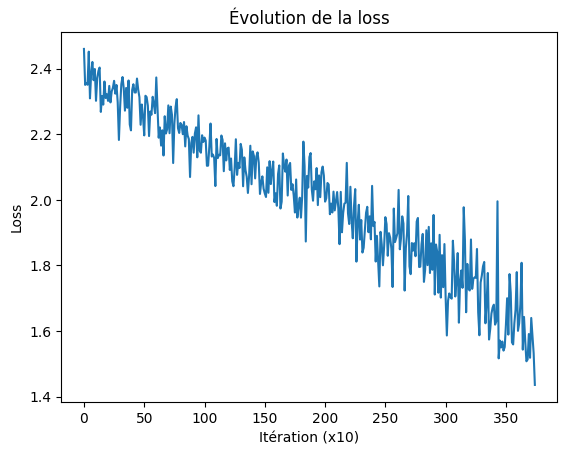

In [12]:
batch_size = 32
for i in range(0, len(X_train), batch_size):
  x = X_train[i:i+batch_size].reshape(-1, 784).T / 255
  y = y_train[i:i+batch_size]
  LayerProduction["x"] = x.copy()
  FC3 = FullyConnectedLayer(W_FCLayer3, x, b_FCLayer3)
  LayerProduction["FC3_Result"] = FC3.copy()
  ReLU2 = ReLULayer(FC3)
  LayerProduction["ReLU2_Result"] = ReLU2.copy()
  FC2 = FullyConnectedLayer(W_FCLayer2, ReLU2, b_FCLayer2)
  LayerProduction["FC2_Result"] = FC2.copy()
  ReLU1 = ReLULayer(FC2)
  LayerProduction["ReLU1_Result"] = ReLU1.copy()
  FC1 = FullyConnectedLayer(W_FCLayer1, ReLU1, b_FCLayer1)
  LayerProduction["FC1_Result"] = FC1.copy()
  Soft = softmax(FC1)
  y_pred = Soft

  #fin du foreward

  Gra1 = Gradient_1(y, y_pred)
  Gra2 = Gradient2(ReLU1, Gra1)
  Gra3 = Gradient3(FC2, Gra1, W_FCLayer1)
  Gra4 = Gradient4(ReLU2, Gra3)
  Gra5 = Gradient5(FC3, Gra3, W_FCLayer2)
  Gra6 = Gradient6(x, Gra5)

  maj_b_FC3 = maj_b(Gra6[1],b_FCLayer3, 0.001)
  maj_W_FC3 = maj_W(Gra6[0],W_FCLayer3, 0.001)

  maj_b_FC2 = maj_b(Gra4[1],b_FCLayer2, 0.001)
  maj_W_FC2 = maj_W(Gra4[0],W_FCLayer2, 0.001)

  maj_b_FC1 = maj_b(Gra2[1],b_FCLayer1, 0.001)
  maj_W_FC1 = maj_W(Gra2[0],W_FCLayer1, 0.001)

  b_FCLayer3 = maj_b_FC3
  W_FCLayer3 = maj_W_FC3
  b_FCLayer2 = maj_b_FC2
  W_FCLayer2 = maj_W_FC2
  b_FCLayer1 = maj_b_FC1
  W_FCLayer1 = maj_W_FC1

  if i % 10 == 0:
    L = Loss(y_pred,y)
    LossStock.append(L)

plt.plot(LossStock)
plt.xlabel("Itération (x10)")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.show()